# FourCastNeXt Inference Demonstration

!Note! This model is not identical to the model from the paper. This version uses a reduced set of variables, has a slightly different grid definition, and uses a simpler training strategy which is easier to explain.

The goal is eventually to provide a version which reproduces the results of the paper, and also a modified version which can support some specific use cases.

Trained models are typically "registered", in similar fashion to the data catalogue, so they can be easily accessed by name using a common API. Models can be accessed either by registered name, or using a lower-level API interaction. For models under development where there may be many different checkpoint files and versions to choose from, it may be preferable to supply various configuration overrides to easily switch between experiment runs.

Model inferencing can be done:
 1. Inside a Jupyter notebook, as Python code
 2. From the command-line or in a Jupyter notebook using the command-line execution magic, leveraging "Hydra" for experiment tracking
 3. Interactively from the command-line using the 'pet predict' command which will ask the user about data and configuration preferences
 4. Using a supercomputer job scheduler to submit training jobs as part of a queuing system

This notebook will start with the first approach to illuminate the process, but for those involved in research into new model archictures, (2) and (3) offer more flexibility for validating multiple models at once, and for operating across multiple HPC nodes or cloud instances to accelerate training and discovery.

Model researchers will also be interested in validating trained models to ensure they perform well on a scorecard of metrics, and not limit their analysis to loss function fitting performance. Standardised validation will be added to PyEarthTools in coming months and validation is beyond the scope of this notebook.

## Inferencing full model

In [1]:
%%capture
# %%capture is included so that debugging output isn't presented in the docs,
# users may find the output helpful

# Note - this would more commonly be loaded from a supplied configuration file, but this approach spells 
# out how to do it using code if wanted, and users can experiment with modifying the pipeline more easily.

import pyearthtools.pipeline
import site_archive_nci
import fourcastnext
data_pipeline = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.archive.ERA5(["msl", "10u", "10v", "2t"]),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    fourcastnext.CropToRectangle(),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((-6, 1), (6, 2, 6))
    ),    
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
)

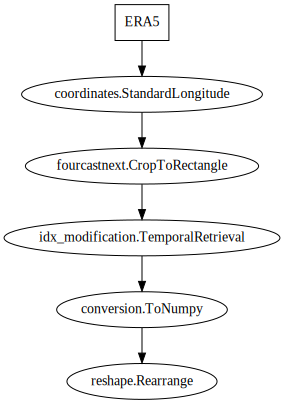

In [2]:
data_pipeline

In [3]:
# Uncomment this to see a sample drawn from the pipeline
# data_pipeline['2001-01-01T00']

In [4]:
# The pipeline we are going to actually use is defined by name and loaded from configuration
# It is the same as the one used above. We need to adjust the API for the registered model
# interface to allow the provision of an instantiated pipeline. In practise, however,
# the configuration approach is ultimately more robust after initial exploration
model = fourcastnext.registered_model.FourCastNextRM(
    pipeline='early_stopping',
    output='.',
    ckpt_path='/scratch/kd24/ML/model-epoch=00-step=5000.ckpt',
    lead_time=24
)

In [5]:
%%capture
# %%capture is included so that debugging output isn't presented in the docs,
# users may find the output helpful
prediction = model.run('2001-01-01T00')

In [6]:
prediction

<xarray.Dataset> Size: 66MB
Dimensions:    (time: 4, latitude: 720, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.25 -89.5 -89.75
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time       (time) datetime64[ns] 32B 2001-01-01T06:00:00 ... 2001-01-02
Data variables:
    msl        (time, latitude, longitude) float32 17MB 1.032e+05 ... 1.018e+05
    t2m        (time, latitude, longitude) float32 17MB 250.6 251.6 ... 243.4
    u10        (time, latitude, longitude) float32 17MB -1.14 ... -0.04982
    v10        (time, latitude, longitude) float32 17MB -2.262 -1.345 ... 1.987
Attributes:
    Conventions:          CF-1.6
    license:              Licence to use Copernicus Products: https://apps.ec...
    summary:              ERA5 is the fifth generation ECMWF atmospheric rean...
    pyearthtools_models:  Development/FourCastNextRM: 0.1.0
    purpose:              Research Use Only.
    contact:              For further information or support, contact the Dat...
    crpyearthtools:       Generated with `pyearthtools`, a research endeavour...

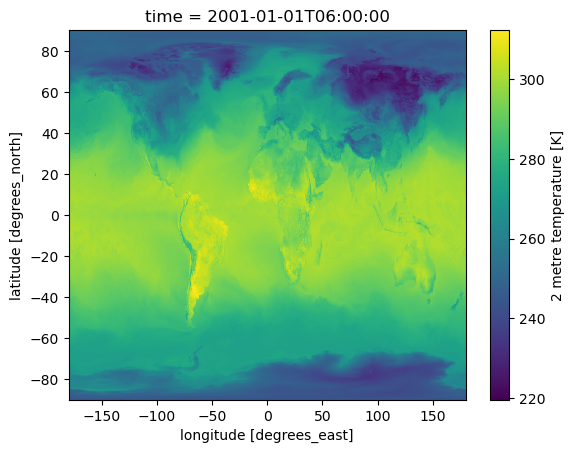

In [7]:
prediction.t2m[0].plot()

In [8]:
%%capture
# %%capture is included so that debugging output isn't presented in the docs,
# users may find the output helpful
model.run('2001-06-01T00').t2m[0].plot()